# Generating the Sets: Train. Validation, Test, Calibration

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pyprojroot import here
from sklearn.model_selection import train_test_split

## Path and Files Names

In [3]:
RAW_DATA_PATH = here() / "data" / "raw"
PROCESSED_DATA_PATH = here() / "data" / "processed"

In [4]:
FULL_PROC_SMRT_FILE = PROCESSED_DATA_PATH / "proc_SMRT_dataset.csv"

## Load the Full Dataset and Check the Distribution

In [5]:
full_smrt_df = pd.read_csv(FULL_PROC_SMRT_FILE, sep=";")
print(full_smrt_df.shape)
full_smrt_df.head()

(79938, 4)


,pubchem,rt,inchi,SMILES
0,5139,93.5,"InChI=1S/C3H8N2S/c1-2-6-3(4)5/h2H2,1H3,(H3,4,5)",CCSC(=N)N
1,3505,687.8,InChI=1S/C19H25Cl2N3O3/c1-27-19(26)23-8-9-24(1...,COC(=O)N1CCN(C(=O)Cc2ccc(Cl)c(Cl)c2)[C@H](CN2C...
2,2159,590.7,InChI=1S/C17H27N3O4S/c1-4-20-8-6-7-12(20)11-19...,CCN1CCC[C@@H]1CN=C(O)c1cc(S(=O)(=O)CC)c(N)cc1OC
3,1340,583.6,InChI=1S/C9H7NO2/c11-8-3-1-2-7-6(8)4-5-10-9(7)...,Oc1cccc2c(O)nccc12
4,3344,579.0,InChI=1S/C15H20N2O2/c18-14-16-12-15(19-14)7-10...,OC1=NCC2(CCN(CCc3ccccc3)CC2)O1


Let's take a pick at the distribution of the retention times

<Axes: ylabel='Frequency'>

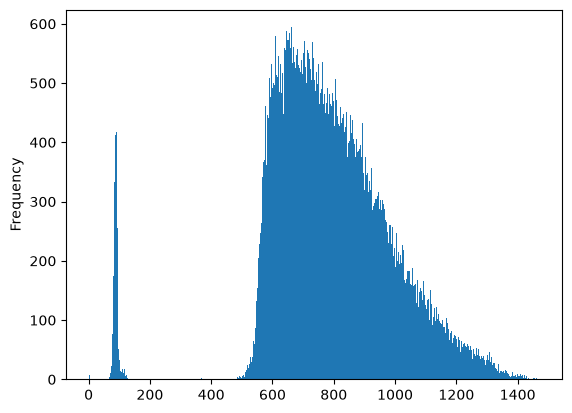

In [6]:
full_smrt_df['rt'].plot.hist(bins=500)

So clearly there a two dsitibutions there. Molecules with rt under 120 seconds are considered not retained and are usually ignore in the literature. We will generate the sets without dropping those nonretained molecules. Lateron, we will train models excluding those molecules (as it has been done in the scientific literature). We will invetigate the effect of such action in a future study.

Antway, it is clearly that if we want all sets to be representative, we need to stratify our splits based on the retention times.

Let's create 100 bins and use then to stratify the splits

In [7]:
rt_bins = pd.qcut(full_smrt_df['rt'], 50, labels=list(range(1,51)))
len(rt_bins)

79938

In [8]:
full_smrt_df['bins'] = rt_bins
full_smrt_df.head()

,pubchem,rt,inchi,SMILES,bins
0,5139,93.5,"InChI=1S/C3H8N2S/c1-2-6-3(4)5/h2H2,1H3,(H3,4,5)",CCSC(=N)N,2
1,3505,687.8,InChI=1S/C19H25Cl2N3O3/c1-27-19(26)23-8-9-24(1...,COC(=O)N1CCN(C(=O)Cc2ccc(Cl)c(Cl)c2)[C@H](CN2C...,16
2,2159,590.7,InChI=1S/C17H27N3O4S/c1-4-20-8-6-7-12(20)11-19...,CCN1CCC[C@@H]1CN=C(O)c1cc(S(=O)(=O)CC)c(N)cc1OC,5
3,1340,583.6,InChI=1S/C9H7NO2/c11-8-3-1-2-7-6(8)4-5-10-9(7)...,Oc1cccc2c(O)nccc12,4
4,3344,579.0,InChI=1S/C15H20N2O2/c18-14-16-12-15(19-14)7-10...,OC1=NCC2(CCN(CCc3ccccc3)CC2)O1,4


## Generate the Sets

In [9]:
all_features = full_smrt_df[['SMILES']].to_numpy().squeeze()
all_targets = full_smrt_df[['rt']].to_numpy().squeeze()
all_bins = full_smrt_df[['bins']].to_numpy().squeeze()

In [10]:
train_val_features, test_cal_features, train_val_targets, test_cal_targets, train_val_bins, test_cal_bins = train_test_split(all_features, all_targets, all_bins, stratify=all_bins, test_size=0.15, random_state=123456)
print(train_val_features.shape, test_cal_features.shape)
print(train_val_targets.shape, test_cal_targets.shape)
print(train_val_bins.shape, test_cal_bins.shape)

(67947,) (11991,)
(67947,) (11991,)
(67947,) (11991,)


In [11]:
train_features, val_features, train_targets, val_targets, train_bins, val_bins = train_test_split(train_val_features, train_val_targets, train_val_bins, stratify=train_val_bins, test_size=0.10, random_state=123456)
print(train_features.shape, val_features.shape)
print(train_targets.shape, val_targets.shape)
print(train_bins.shape, val_bins.shape)

(61152,) (6795,)
(61152,) (6795,)
(61152,) (6795,)


In [12]:
test_features, cal_features, test_targets, cal_targets, test_bins, cal_bins = train_test_split(test_cal_features, test_cal_targets, test_cal_bins, stratify=test_cal_bins, test_size=1000, random_state=123456)
print(test_features.shape, cal_features.shape)
print(test_targets.shape, cal_targets.shape)
print(test_bins.shape, cal_bins.shape)

(10991,) (1000,)
(10991,) (1000,)
(10991,) (1000,)


Let's create a dataframe to plot the different sets

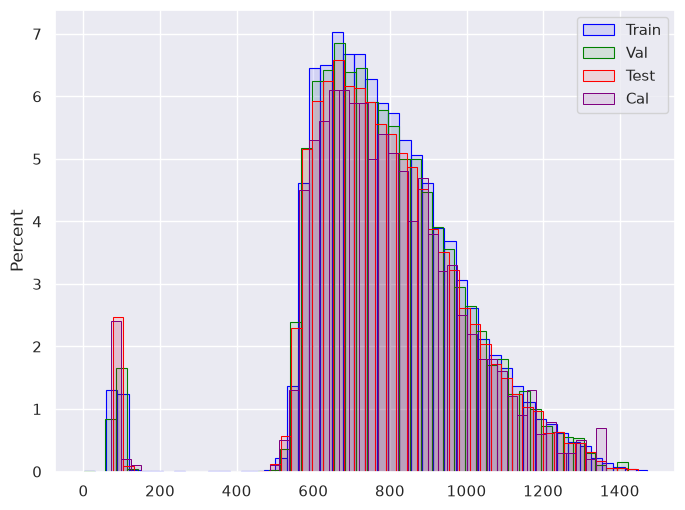

In [13]:
#sns.reset_defaults()
sns.set_theme(style="darkgrid")
my_fig, my_ax = plt.subplots(figsize=(8, 6))
num_bins = 50
my_ax = sns.histplot(data=train_targets, stat="percent", alpha=0.1, label="Train", bins=num_bins, color="blue", edgecolor='blue', ax=my_ax)
my_ax = sns.histplot(data=val_targets, stat="percent", alpha=0.1, label="Val", bins=num_bins, color="green", edgecolor='green', ax=my_ax)
my_ax = sns.histplot(data=test_targets, stat="percent", alpha=0.1, label="Test", bins=num_bins, color="red", edgecolor='red', ax=my_ax)
my_ax = sns.histplot(data=cal_targets, stat="percent", alpha=0.1, label="Cal", bins=num_bins, color="purple", edgecolor='purple', ax=my_ax)
plt.legend()
plt.show()

## Save the Sets

In [14]:
# Train
np.save(PROCESSED_DATA_PATH / "X_train_set.npy", train_features)
np.save(PROCESSED_DATA_PATH / "y_train_set.npy", train_targets)
# Validation
np.save(PROCESSED_DATA_PATH / "X_val_set.npy", val_features)
np.save(PROCESSED_DATA_PATH / "y_val_set.npy", val_targets)
# Train
np.save(PROCESSED_DATA_PATH / "X_test_set.npy", test_features)
np.save(PROCESSED_DATA_PATH / "y_test_set.npy", test_targets)
# Calibration
np.save(PROCESSED_DATA_PATH / "X_cal_set.npy", cal_features)
np.save(PROCESSED_DATA_PATH / "y_cal_set.npy", cal_targets)

In [15]:
print(len(train_features))
print(len(train_features[train_targets > 120]))
print(len(train_features[train_targets <= 120]))

61152
59593
1559


In [16]:
# Train
np.save(PROCESSED_DATA_PATH / "X_train_set_retained.npy", train_features[train_targets > 120])
np.save(PROCESSED_DATA_PATH / "y_train_set_retained.npy", train_targets[train_targets > 120])
# Validation
np.save(PROCESSED_DATA_PATH / "X_val_set_retained.npy", val_features[val_targets > 120])
np.save(PROCESSED_DATA_PATH / "y_val_set_retained.npy", val_targets[val_targets > 120])
# Train
np.save(PROCESSED_DATA_PATH / "X_test_set_retained.npy", test_features[test_targets > 120])
np.save(PROCESSED_DATA_PATH / "y_test_set_retained.npy", test_targets[test_targets > 120])
# Calibration
np.save(PROCESSED_DATA_PATH / "X_cal_set_retained.npy", cal_features[cal_targets > 120])
np.save(PROCESSED_DATA_PATH / "y_cal_set_retained.npy", cal_targets[cal_targets > 120])

In [17]:
# Train
np.save(PROCESSED_DATA_PATH / "X_train_set_unretained.npy", train_features[train_targets <= 120])
np.save(PROCESSED_DATA_PATH / "y_train_set_unretained.npy", train_targets[train_targets <= 120])
# Validation
np.save(PROCESSED_DATA_PATH / "X_val_set_unretained.npy", val_features[val_targets <= 120])
np.save(PROCESSED_DATA_PATH / "y_val_set_unretained.npy", val_targets[val_targets <= 120])
# Train
np.save(PROCESSED_DATA_PATH / "X_test_set_unretained.npy", test_features[test_targets <= 120])
np.save(PROCESSED_DATA_PATH / "y_test_set_unretained.npy", test_targets[test_targets <= 120])
# Calibration
np.save(PROCESSED_DATA_PATH / "X_cal_set_unretained.npy", cal_features[cal_targets <= 120])
np.save(PROCESSED_DATA_PATH / "y_cal_set_unretained.npy", cal_targets[cal_targets <= 120])